# k-NN Classifier on VGG-16 Block4 Pool Features

This notebook compares three k-nearest-neighbors variants on the precomputed feature extraction artefacts from Alena's archive.

The goal is not only to find the best score, but also to make the modeling choices explainable:

1. **Euclidean majority KNN**: every neighbor gets one vote.
2. **Euclidean distance-weighted KNN**: closer neighbors get stronger votes.
3. **Cosine distance-weighted KNN**: compares feature direction instead of raw Euclidean distance.


In [13]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import wandb
from wandb.errors import CommError
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

config_params = {
    "model_type": "KNN comparison",
    "feature_source": "vgg16_block4pool_alena_archive",
    "feature_dimensions": 512,
    "n_neighbors": 5,
    "approaches": [
        "euclidean_majority",
        "euclidean_distance_weighted",
        "cosine_distance_weighted",
    ],
    "implementation": "exact_batched_torch",
    "batch_size": 64,
    "test_size": 0.20,
    "random_state": 42,
}

os.environ.setdefault("WANDB_NOTEBOOK_NAME", "notebooks/04_knn.ipynb")

wandb_mode = os.environ.get("WANDB_MODE")
if not wandb_mode and not os.environ.get("WANDB_API_KEY") and not Path.home().joinpath("_netrc").exists():
    wandb_mode = "offline"
    os.environ["WANDB_MODE"] = wandb_mode
    print("WANDB_API_KEY/_netrc not found. Falling back to offline wandb mode.")

wandb_init_kwargs = {
    "project": "odysseus",
    "name": "vgg16_block4pool_knn_comparison",
    "job_type": "modeling",
    "config": config_params,
    "mode": wandb_mode,
    "save_code": False,
}

try:
    wandb.init(**wandb_init_kwargs)
except CommError as exc:
    if wandb_mode == "offline":
        raise
    print(f"wandb login unavailable ({exc}). Falling back to offline mode.")
    os.environ["WANDB_MODE"] = "offline"
    wandb_mode = "offline"
    wandb.init(**{**wandb_init_kwargs, "mode": wandb_mode})
config = wandb.config


In [2]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "extracted_features_alena").exists():
            return path
    raise FileNotFoundError(
        "Could not find data/extracted_features_alena from the current working directory."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "extracted_features_alena"
print(f"Project root: {PROJECT_ROOT}")
print(f"Feature directory: {DATA_DIR}")


X = np.load(DATA_DIR / "features_block4pool.npy")
y = np.load(DATA_DIR / "labels_block4pool.npy")

with open(DATA_DIR / "class_indices.json", "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in sorted(idx_to_class)]

print(f"Loaded X: {X.shape}, y: {y.shape}")
print(f"Classes: {len(class_names)}")
print(class_names)

assert X.ndim == 2, f"Expected 2D feature matrix, got shape {X.shape}"
assert y.ndim == 1, f"Expected 1D labels, got shape {y.shape}"
assert len(X) == len(y), "Feature and label counts do not match"
assert X.shape[1] == config.feature_dimensions, (
    f"Expected {config.feature_dimensions} features, got {X.shape[1]}"
)

Project root: C:\Users\marti\Documents\GitHub\odysseus
Feature directory: C:\Users\marti\Documents\GitHub\odysseus\data\extracted_features_alena
Loaded X: (55329, 512), y: (55329,)
Classes: 24
['Alpha', 'Beta', 'Chi', 'Delta', 'Epsilon', 'Eta', 'Gamma', 'Iota', 'Kappa', 'Lambda', 'LunateSigma', 'Mu', 'Nu', 'Omega', 'Omicron', 'Phi', 'Pi', 'Psi', 'Rho', 'Tau', 'Theta', 'Upsilon', 'Xi', 'Zeta']


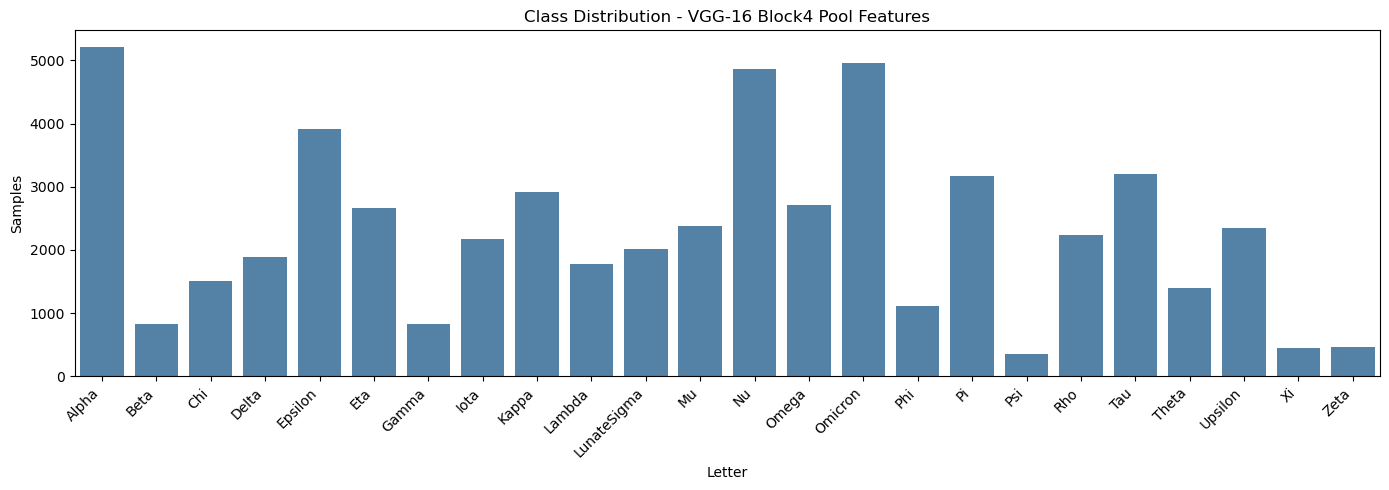

{'Alpha': 5216,
 'Beta': 821,
 'Chi': 1516,
 'Delta': 1881,
 'Epsilon': 3921,
 'Eta': 2660,
 'Gamma': 829,
 'Iota': 2166,
 'Kappa': 2922,
 'Lambda': 1770,
 'LunateSigma': 2014,
 'Mu': 2386,
 'Nu': 4859,
 'Omega': 2707,
 'Omicron': 4958,
 'Phi': 1117,
 'Pi': 3163,
 'Psi': 352,
 'Rho': 2240,
 'Tau': 3195,
 'Theta': 1396,
 'Upsilon': 2340,
 'Xi': 441,
 'Zeta': 459}

In [3]:
unique_labels, label_counts = np.unique(y, return_counts=True)
distribution = {
    idx_to_class[int(label)]: int(count)
    for label, count in zip(unique_labels, label_counts)
}

plt.figure(figsize=(14, 5))
sns.barplot(x=list(distribution.keys()), y=list(distribution.values()), color="steelblue")
plt.title("Class Distribution - VGG-16 Block4 Pool Features")
plt.xlabel("Letter")
plt.ylabel("Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("knn_class_distribution.png", dpi=300)
wandb.log({"class_distribution": wandb.Image("knn_class_distribution.png")})
plt.show()

distribution

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config.test_size,
    random_state=config.random_state,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (44263, 512), Test: (11066, 512)


In [5]:
def _as_float_tensor(array):
    return torch.from_numpy(array.astype(np.float32, copy=False))


def _majority_vote(nn_labels, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, labels in enumerate(nn_labels):
        counts = torch.bincount(labels.long(), minlength=n_classes)
        y_pred[row_idx] = int(counts.argmax())
    return y_pred


def _weighted_vote(nn_labels, weights, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, (labels, row_weights) in enumerate(zip(nn_labels, weights)):
        scores = torch.zeros(n_classes, dtype=torch.float64)
        scores.scatter_add_(0, labels.long(), row_weights.double())
        y_pred[row_idx] = int(scores.argmax())
    return y_pred


def predict_knn_euclidean(X_train, y_train, X_test, n_classes, k=5, batch_size=64, weighted=False):
    train = _as_float_tensor(X_train)
    test = _as_float_tensor(X_test)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    train_norm = (train * train).sum(dim=1)
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        dists_sq = (batch * batch).sum(dim=1, keepdim=True) + train_norm[None, :] - 2 * batch.matmul(train_t)
        nn_dists_sq, nn_idx = torch.topk(dists_sq, k=k, largest=False, dim=1)
        nn_labels = y_train_t[nn_idx]

        if weighted:
            weights = 1 / (torch.sqrt(torch.clamp(nn_dists_sq, min=0)) + 1e-12)
            batch_pred = _weighted_vote(nn_labels, weights, n_classes)
        else:
            batch_pred = _majority_vote(nn_labels, n_classes)

        y_pred[start_idx:end_idx] = batch_pred
        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred


def predict_knn_cosine_weighted(X_train, y_train, X_test, n_classes, k=5, batch_size=64):
    train = _as_float_tensor(X_train)
    test = _as_float_tensor(X_test)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train = torch.nn.functional.normalize(train, p=2, dim=1)
    test = torch.nn.functional.normalize(test, p=2, dim=1)
    train_t = train.T.contiguous()
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        similarities = batch.matmul(train_t)
        nn_similarities, nn_idx = torch.topk(similarities, k=k, largest=True, dim=1)
        nn_labels = y_train_t[nn_idx]
        cosine_distances = 1 - nn_similarities
        weights = 1 / (torch.clamp(cosine_distances, min=0) + 1e-12)
        y_pred[start_idx:end_idx] = _weighted_vote(nn_labels, weights, n_classes)

        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred


def evaluate_predictions(name, y_true, y_pred):
    return {
        "approach": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }


## KNN approaches compared

All three models use the same train/test split and the same value of `k`. This means score differences come from the decision rule, not from different data.

- **Euclidean majority KNN** chooses the class that appears most often among the nearest neighbors. It is simple and robust, but treats the closest and the k-th closest neighbor equally.
- **Euclidean distance-weighted KNN** still uses Euclidean distance, but neighbors close to the test sample receive more voting weight. This often helps when the closest match is much more relevant than the rest.
- **Cosine distance-weighted KNN** normalizes vectors and compares their direction. For neural-network feature vectors this can be useful because the activation pattern can matter more than the absolute vector length.


In [6]:
knn_runs = [
    {
        "name": "euclidean_majority",
        "description": "Euclidean distance + unweighted majority vote",
        "predict": lambda: predict_knn_euclidean(
            X_train_scaled,
            y_train,
            X_test_scaled,
            n_classes=len(class_names),
            k=config.n_neighbors,
            batch_size=config.batch_size,
            weighted=False,
        ),
    },
    {
        "name": "euclidean_distance_weighted",
        "description": "Euclidean distance + inverse-distance vote weighting",
        "predict": lambda: predict_knn_euclidean(
            X_train_scaled,
            y_train,
            X_test_scaled,
            n_classes=len(class_names),
            k=config.n_neighbors,
            batch_size=config.batch_size,
            weighted=True,
        ),
    },
    {
        "name": "cosine_distance_weighted",
        "description": "Cosine distance + inverse-distance vote weighting",
        "predict": lambda: predict_knn_cosine_weighted(
            X_train_scaled,
            y_train,
            X_test_scaled,
            n_classes=len(class_names),
            k=config.n_neighbors,
            batch_size=config.batch_size,
        ),
    },
]

predictions = {}
results = []

for run in knn_runs:
    print(f"\nRunning {run['name']}: {run['description']}")
    y_pred_run = run["predict"]()
    predictions[run["name"]] = y_pred_run
    metrics = evaluate_predictions(run["name"], y_test, y_pred_run)
    metrics["description"] = run["description"]
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_df




Running euclidean_majority: Euclidean distance + unweighted majority vote
Predicted 640/11066
Predicted 1280/11066
Predicted 1920/11066
Predicted 2560/11066
Predicted 3200/11066
Predicted 3840/11066
Predicted 4480/11066
Predicted 5120/11066
Predicted 5760/11066
Predicted 6400/11066
Predicted 7040/11066
Predicted 7680/11066
Predicted 8320/11066
Predicted 8960/11066
Predicted 9600/11066
Predicted 10240/11066
Predicted 10880/11066
Predicted 11066/11066

Running euclidean_distance_weighted: Euclidean distance + inverse-distance vote weighting
Predicted 640/11066
Predicted 1280/11066
Predicted 1920/11066
Predicted 2560/11066
Predicted 3200/11066
Predicted 3840/11066
Predicted 4480/11066
Predicted 5120/11066
Predicted 5760/11066
Predicted 6400/11066
Predicted 7040/11066
Predicted 7680/11066
Predicted 8320/11066
Predicted 8960/11066
Predicted 9600/11066
Predicted 10240/11066
Predicted 10880/11066
Predicted 11066/11066

Running cosine_distance_weighted: Cosine distance + inverse-distance vote

,approach,accuracy,macro_f1,weighted_f1,description
0,euclidean_distance_weighted,0.551690,0.488469,0.545191,Euclidean distance + inverse-distance vote wei...
1,cosine_distance_weighted,0.555666,0.488135,0.548035,Cosine distance + inverse-distance vote weighting
2,euclidean_majority,0.540484,0.474789,0.534936,Euclidean distance + unweighted majority vote


In [7]:
best_row = results_df.iloc[0]
best_approach = best_row["approach"]
y_pred = predictions[best_approach]
accuracy = best_row["accuracy"]
macro_f1 = best_row["macro_f1"]
weighted_f1 = best_row["weighted_f1"]

print("Best KNN approach:")
print(f"- Approach: {best_approach}")
print(f"- Accuracy: {accuracy:.4f}")
print(f"- Macro-F1: {macro_f1:.4f}")
print(f"- Weighted-F1: {weighted_f1:.4f}")

wandb.run.summary["best_knn_approach"] = best_approach
wandb.run.summary["best_accuracy"] = accuracy
wandb.run.summary["best_macro_f1"] = macro_f1
wandb.run.summary["best_weighted_f1"] = weighted_f1

for row in results:
    prefix = row["approach"]
    wandb.run.summary[f"{prefix}_accuracy"] = row["accuracy"]
    wandb.run.summary[f"{prefix}_macro_f1"] = row["macro_f1"]
    wandb.run.summary[f"{prefix}_weighted_f1"] = row["weighted_f1"]

wandb.log({"knn_comparison": wandb.Table(dataframe=results_df)})


Best KNN approach:
- Approach: euclidean_distance_weighted
- Accuracy: 0.5517
- Macro-F1: 0.4885
- Weighted-F1: 0.5452


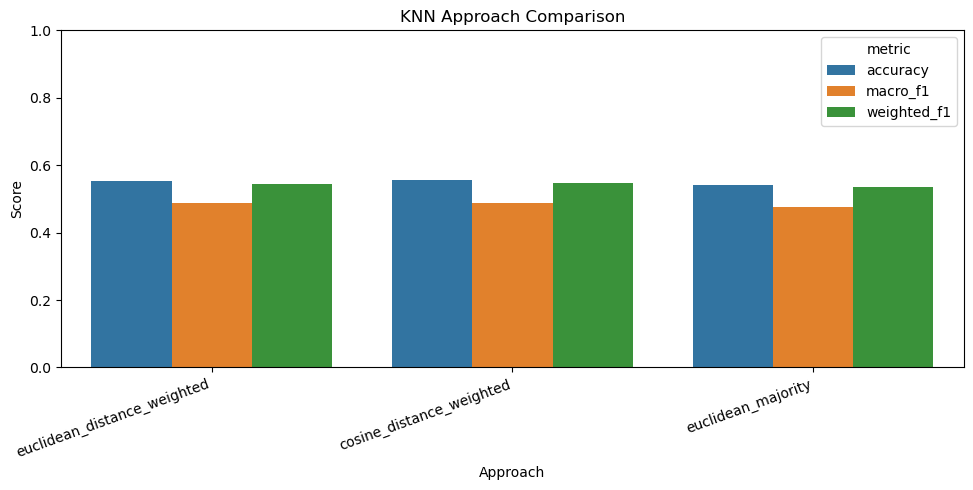

In [8]:
plt.figure(figsize=(10, 5))
plot_df = results_df.melt(
    id_vars="approach",
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="approach", y="score", hue="metric")
plt.title("KNN Approach Comparison")
plt.xlabel("Approach")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("knn_approach_comparison.png", dpi=300)
wandb.log({"knn_approach_comparison": wandb.Image("knn_approach_comparison.png")})
plt.show()


In [9]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
)

print(f"Classification Report for best approach: {best_approach}")
print(report)


Classification Report for best approach: euclidean_distance_weighted
              precision    recall  f1-score   support

       Alpha     0.5513    0.6280    0.5872      1043
        Beta     0.3806    0.3110    0.3423       164
         Chi     0.5311    0.4785    0.5035       303
       Delta     0.6923    0.5266    0.5982       376
     Epsilon     0.5296    0.6046    0.5646       784
         Eta     0.4664    0.5602    0.5090       532
       Gamma     0.3544    0.1687    0.2286       166
        Iota     0.5648    0.5035    0.5324       433
       Kappa     0.5220    0.5487    0.5350       585
      Lambda     0.4325    0.3079    0.3597       354
 LunateSigma     0.4425    0.3821    0.4101       403
          Mu     0.5775    0.5157    0.5449       477
          Nu     0.5744    0.7582    0.6537       972
       Omega     0.6760    0.6236    0.6488       542
     Omicron     0.6088    0.6260    0.6173       992
         Phi     0.6687    0.4798    0.5587       223
          Pi

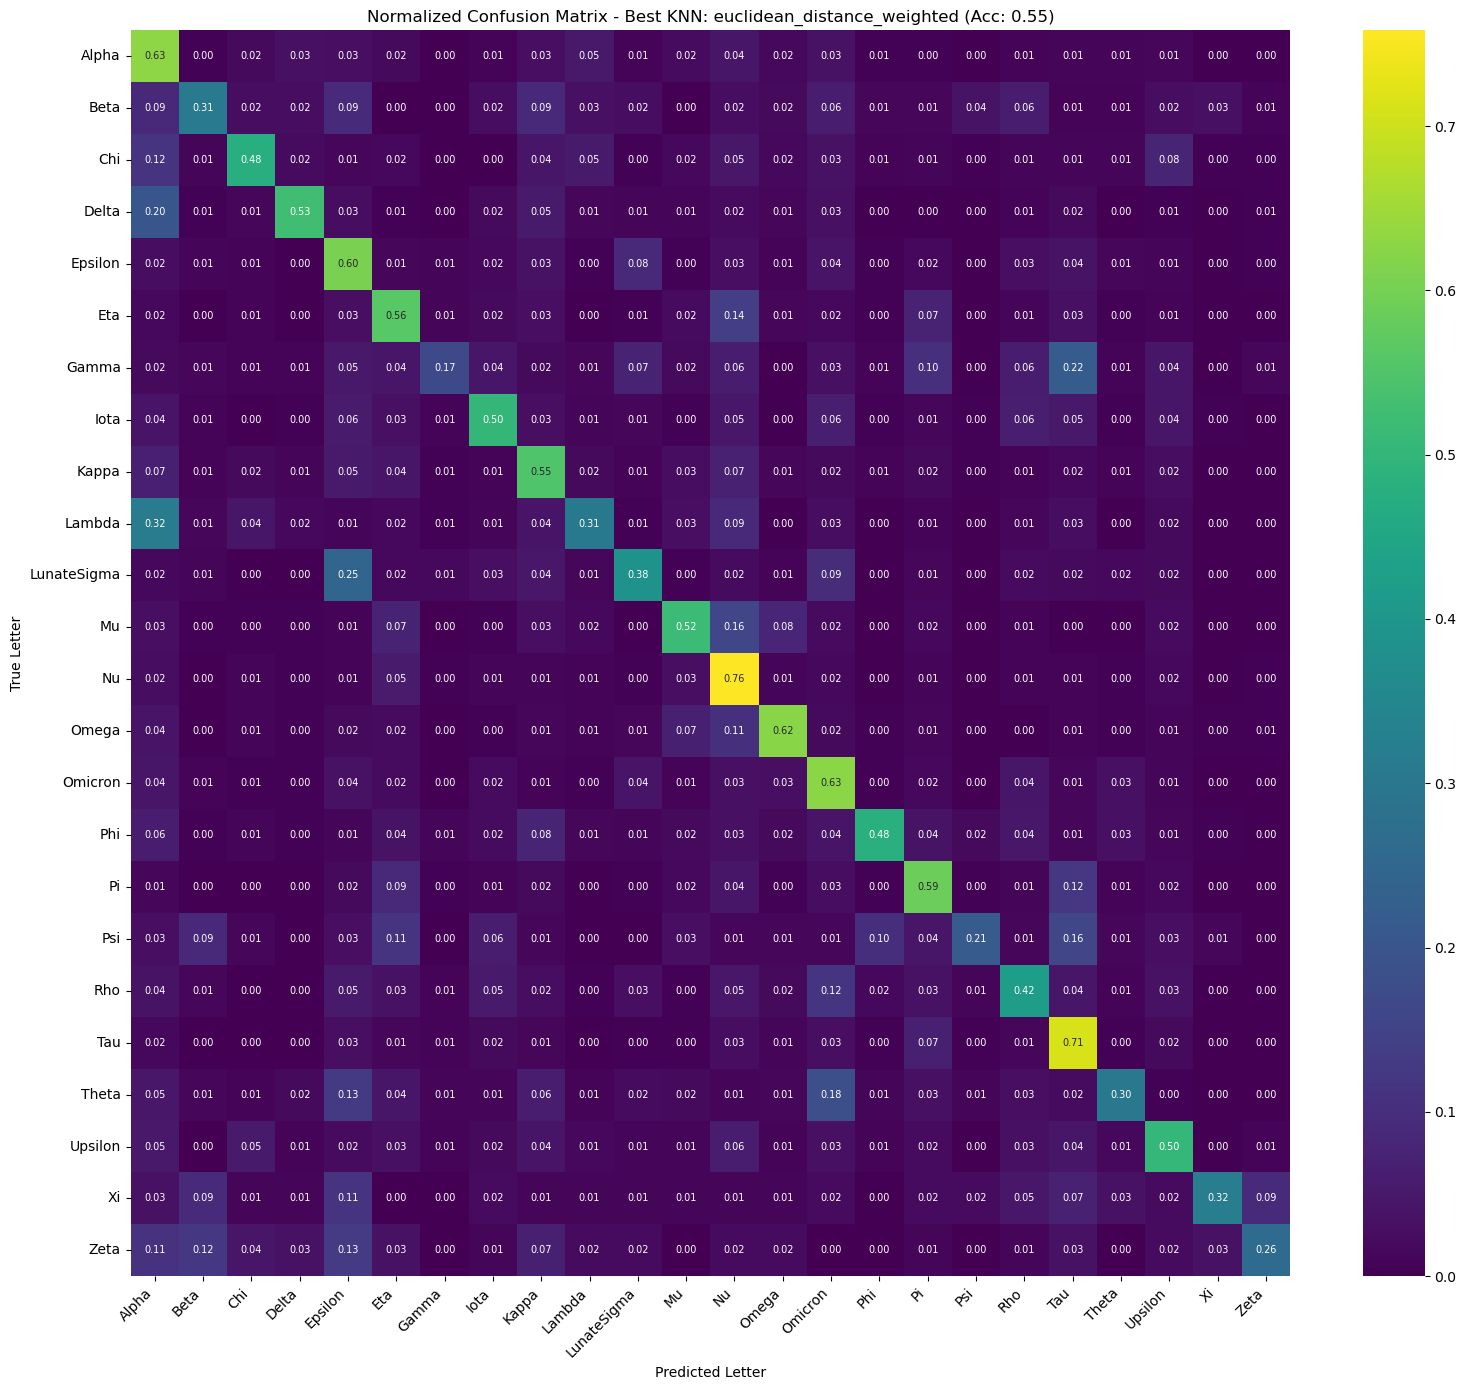

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(idx_to_class), normalize="true")

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 7},
)
plt.title(f"Normalized Confusion Matrix - Best KNN: {best_approach} (Acc: {accuracy:.2f})")
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("knn_confusion_matrix.png", dpi=300)
wandb.log({"confusion_matrix_annotated": wandb.Image("knn_confusion_matrix.png")})
plt.show()


## Interpretation guide for the report

Use **macro-F1** as the main comparison metric if every Greek letter class should count equally. Macro-F1 averages the class-wise F1 scores and is therefore stricter when some letters are harder to classify. Accuracy and weighted-F1 can look better when frequent classes dominate the test set.

A good explanation of the result should mention both the distance metric and the voting rule:

- If **Euclidean majority KNN** wins, the feature space already separates classes well and extra weighting adds little benefit.
- If **Euclidean distance-weighted KNN** wins, the nearest examples are more trustworthy than the rest of the neighborhood.
- If **Cosine distance-weighted KNN** wins, the direction of the VGG feature vector is more informative than its absolute magnitude.


In [11]:
wandb.finish()


best_accuracy,0.55169
best_knn_approach,euclidean_distance_w...
best_macro_f1,0.48847
best_weighted_f1,0.54519
cosine_distance_weighted_accuracy,0.55567
cosine_distance_weighted_macro_f1,0.48813
cosine_distance_weighted_weighted_f1,0.54803
euclidean_distance_weighted_accuracy,0.55169
euclidean_distance_weighted_macro_f1,0.48847
euclidean_distance_weighted_weighted_f1,0.54519
+3,...
